In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import control as ct
wref = 2*math.pi*100*10**6          # your reference Frequency in rad
divider= list(np.arange(20,51))     # your divider range
LookTime = 5*pow(10,-6)             # your Lock time from the specs 
Accuracy = 10**5                    # high accurcy meent large settling time and low ripple amplitude
                                    # the recommended range is between 100 to 100k

In [118]:
zeta = 1/math.sqrt(2)                                                                        # to ensure stability
Tlock_times_Wn = math.log((Accuracy / (math.sqrt(1-zeta**2)))) / zeta
print("tau * wn =",round(Tlock_times_Wn,3))

wn = Tlock_times_Wn / LookTime
print("Min wn =",round(wn/pow(10,6),3),"Mrad  -----> ",round(wn/(pow(10,6)*2*math.pi),3), "MHz")

wc = wn * 2 * zeta
print("Min wc =",round(wc/pow(10,6),3),"Mrad ----->",round(wc/(pow(10,6)*2*math.pi),3), "MHz")

Maxwc = wref/10
print("Max wc =",round(Maxwc/pow(10,6),3),"Mrad ----->",round(Maxwc/(pow(10,6)*2*math.pi),3), "MHz")

tau * wn = 16.772
Min wn = 3.354 Mrad  ----->  0.534 MHz
Min wc = 4.744 Mrad -----> 0.755 MHz
Max wc = 62.832 Mrad -----> 10.0 MHz


In [119]:
print("choose value for wc between ",round(wc/pow(10,6),3),"Mrad and",round(Maxwc/pow(10,6),3),"Mrad")
wcNew = eval(input("Enter the choosed wc"))
print("the choosen value for wc is",wcNew,"Mrad")
wcNew *= pow(10,6)

choose value for wc between  4.744 Mrad and 62.832 Mrad
the choosen value for wc is 30 Mrad


In [120]:
PM = eval(input("Enter the chosen PM"))
print("for PM =",PM,"degree")
PM = PM * math.pi / 180 

C1_over_C2 =  2*( (math.tan(PM))**2 + (math.tan(PM)) * math.sqrt( (math.tan(PM))**2 + 1 ) )
wz = wcNew/math.sqrt(C1_over_C2 + 1 )
print("wz =",round(wz/pow(10,6),3),"Mrad")

R1 = eval(input("Enter the value of R1 in k..."))
R1 *= pow(10,3)

print("C1/C2 =",C1_over_C2)
print("The choosen value for R1 =",R1/pow(10,3),"k")

C1 = 1/(wz*R1)
C2 = C1 / C1_over_C2
print("C1 =",round(C1/pow(10,-12),3),"p")
print("C2 =",round(C2/pow(10,-12),3),"p")

for PM = 60 degree
wz = 8.038 Mrad
C1/C2 = 12.928203230275502
The choosen value for R1 = 8.0 k
C1 = 15.55 p
C2 = 1.203 p


In [121]:
Ceq = (C1 * C2) / (C1 + C2)
wp = 1 /( R1 * Ceq )
wc_Max_PM = math.sqrt(wp * wz )
print("value of wc at MAX PM =",round(wc_Max_PM/pow(10,6),3),"Mrad")
wp = 1 /( R1 * Ceq )
print("Wp3 =",wp/pow(10,6),"Mrad")

kvco = eval(input("Enter the value of Kvco in MHz"))
print("the choosen value for kvco is",kvco,"MHz/V")
kvco *= 10**6*2*np.pi

ICHP = (max(divider) *2*np.pi* C2 * wcNew**2 * math.sqrt((wp**2 + wcNew**2) / (wz**2 + wcNew**2)))/ (kvco)
print("ICHP =",round(ICHP/pow(10,-6),3),"uA")

value of wc at MAX PM = 30.0 Mrad
Wp3 = 111.96152422706629 Mrad
the choosen value for kvco is 250 MHz/V
ICHP = 808.013 uA


### View the Transfer Function and Step Response


  Running Analysis for: Max Divider (N = 50)
[Max Divider] Open Loop - Phase Margin (Pm) = 60.0 degrees
[Max Divider] Open Loop - Wpm = 30.0 M rad/s


C:\Users\Muhme\AppData\Local\Temp\ipykernel_17360\3459269528.py:22: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(H_open_loop, dB=True, deg=True,margins=True, linewidth=2, grid=True)


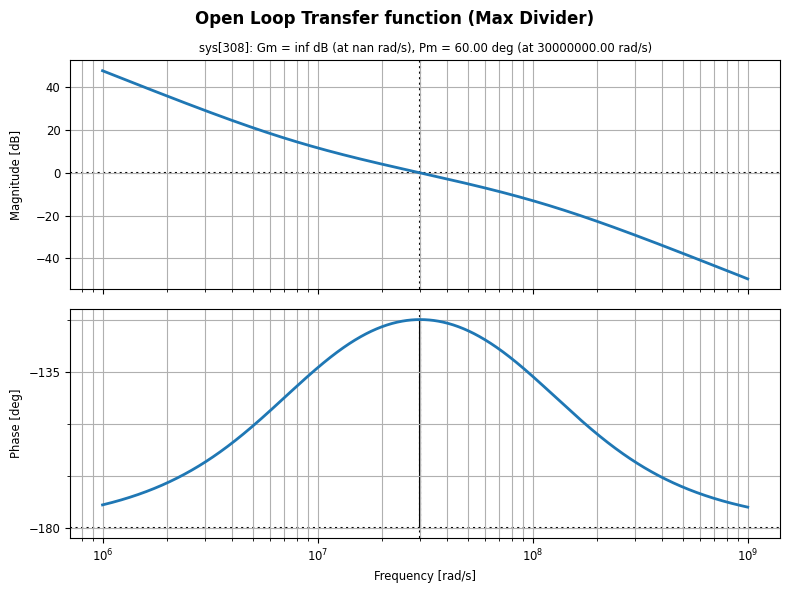

[Max Divider] Closed Loop - Bandwidth = 7.459 MHz
[Max Divider] Closed Loop - Zero Frequency (fz) = 1.279 MHz
[Max Divider] Closed Loop - Pole Frequency (fp) = 17.819 MHz


C:\Users\Muhme\AppData\Local\Temp\ipykernel_17360\3459269528.py:44: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(H_Closed_loop, dB=True, deg=True,margins=True, linewidth=2, grid=True)


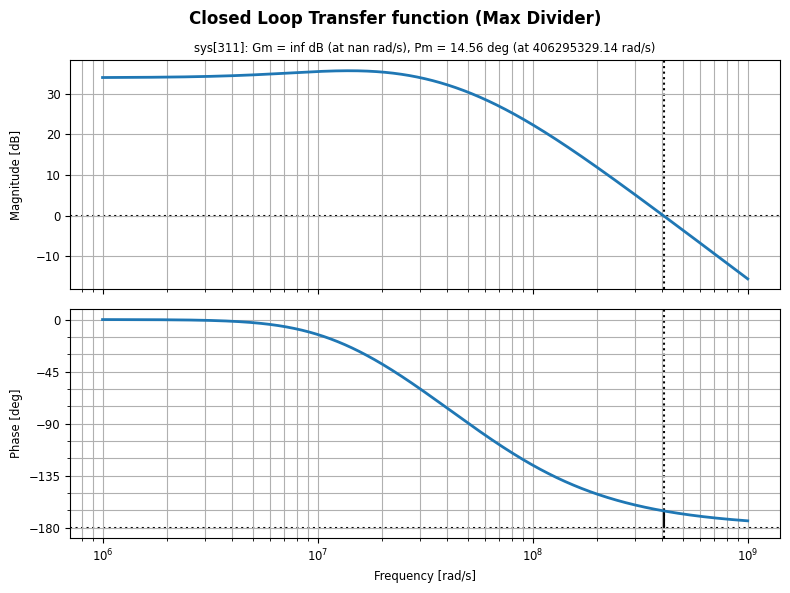

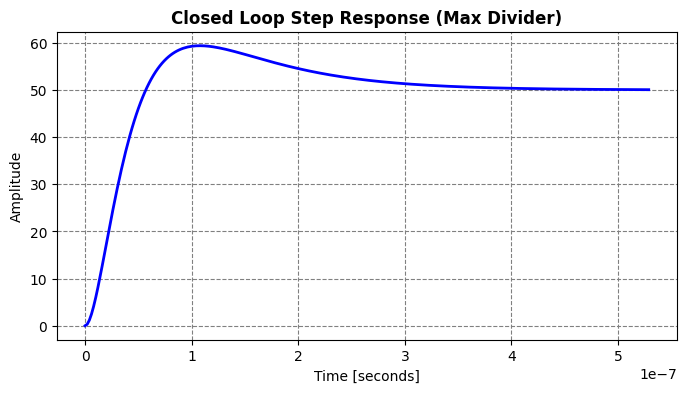


  Running Analysis for: Min Divider (N = 20)
[Min Divider] Open Loop - Phase Margin (Pm) = 52.735 degrees
[Min Divider] Open Loop - Wpm = 65.28 M rad/s


C:\Users\Muhme\AppData\Local\Temp\ipykernel_17360\3459269528.py:22: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(H_open_loop, dB=True, deg=True,margins=True, linewidth=2, grid=True)


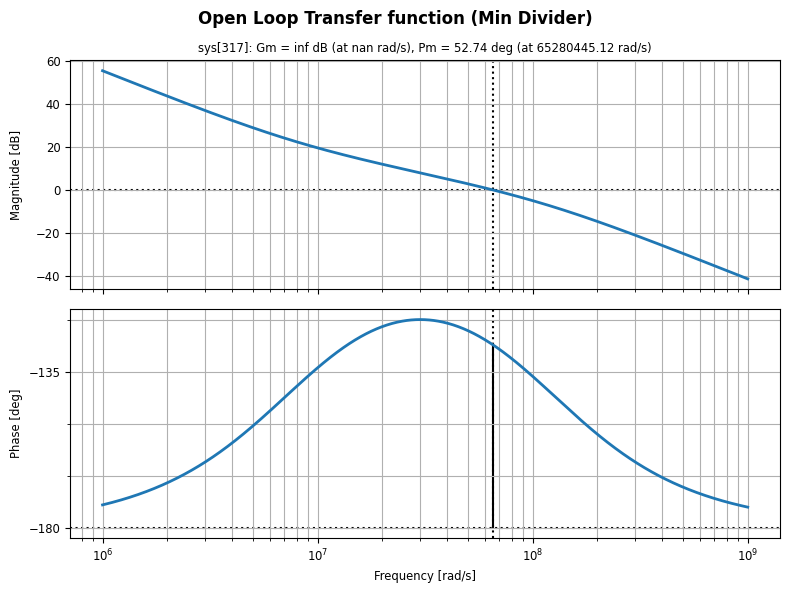

[Min Divider] Closed Loop - Bandwidth = 17.162 MHz
[Min Divider] Closed Loop - Zero Frequency (fz) = 1.279 MHz
[Min Divider] Closed Loop - Pole Frequency (fp) = 17.819 MHz


C:\Users\Muhme\AppData\Local\Temp\ipykernel_17360\3459269528.py:44: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ct.bode_plot(H_Closed_loop, dB=True, deg=True,margins=True, linewidth=2, grid=True)


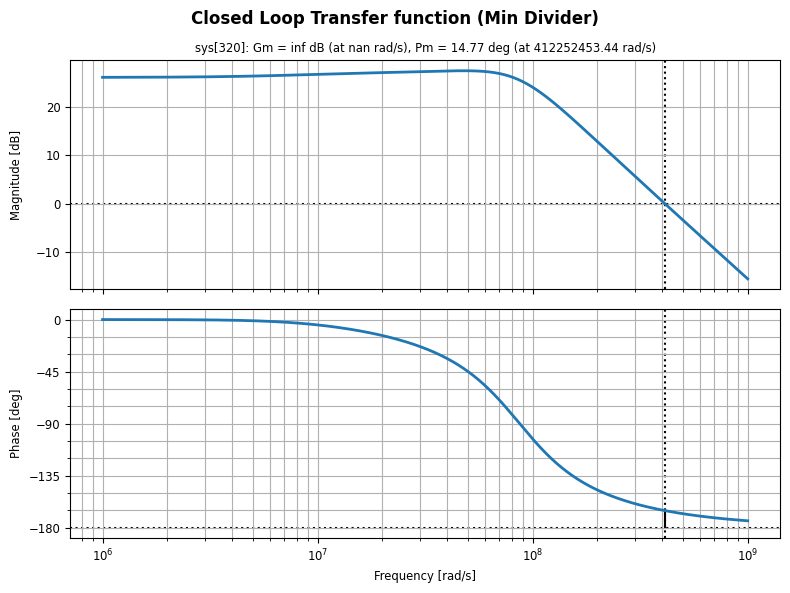

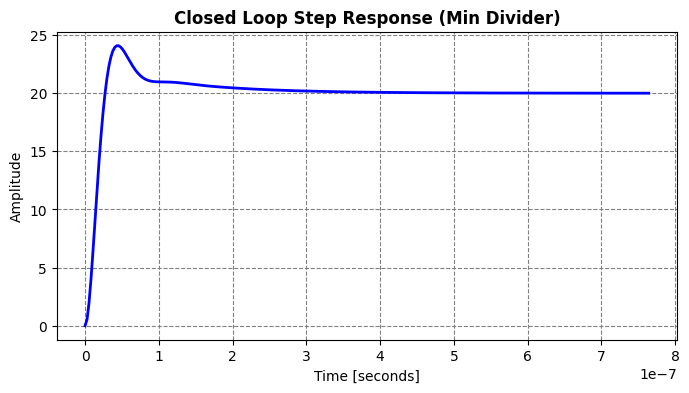

In [122]:
divider_cases = [max(divider), min(divider)]

for N in divider_cases:
    case_name = "Max Divider" if N == max(divider) else "Min Divider"
    print(f"\n" + "="*50)
    print(f"  Running Analysis for: {case_name} (N = {N})")
    print("="*50)
  
    Const1 = (ICHP * kvco) / (2 * np.pi * N * C1 * C2 * R1)

    num_ol = [C1 * R1 * Const1, Const1]
    den_ol = [1, ((C1 + C2) / (C1 * C2 * R1)), 0, 0] 
    
    H_open_loop = ct.tf(num_ol, den_ol)
    Gm, Pm, Wgm, Wpm = ct.margin(H_open_loop)
    Wpm_Mrad = Wpm / 10**6

    print(f"[{case_name}] Open Loop - Phase Margin (Pm) = {round(Pm, 3)} degrees")
    print(f"[{case_name}] Open Loop - Wpm = {round(Wpm_Mrad, 3)} M rad/s")

    plt.figure(figsize=(8, 6))
    ct.bode_plot(H_open_loop, dB=True, deg=True,margins=True, linewidth=2, grid=True)
    
    full_title_ol = f"Open Loop Transfer function ({case_name})"
    plt.suptitle(full_title_ol, fontsize=12, fontweight='bold', y=0.98)
    plt.show()

    num_cl = [C1 * R1 * Const1 * N, N * Const1]
    den_cl = [1, ((C1 + C2) / (C1 * C2 * R1)), (C1 * R1 * Const1), Const1]

    H_Closed_loop = ct.tf(num_cl, den_cl)
    
    BW_rad = ct.bandwidth(H_Closed_loop)
    BW = BW_rad / (2 * np.pi) 
    fz = wz / (2 * np.pi)
    fp = wp / (2 * np.pi) 

    print(f"[{case_name}] Closed Loop - Bandwidth = {round(BW/10**6, 3)} MHz")
    print(f"[{case_name}] Closed Loop - Zero Frequency (fz) = {round(fz/10**6, 3)} MHz")
    print(f"[{case_name}] Closed Loop - Pole Frequency (fp) = {round(fp/10**6, 3)} MHz")


    plt.figure(figsize=(8, 6))
    ct.bode_plot(H_Closed_loop, dB=True, deg=True,margins=True, linewidth=2, grid=True)
        
    full_title_cl = f"Closed Loop Transfer function ({case_name})"
    plt.suptitle(full_title_cl, fontsize=12, fontweight='bold', y=0.98)
    plt.show()

  
    T, Y = ct.step_response(H_Closed_loop)
    
    plt.figure(figsize=(8, 4))
    plt.plot(T, Y, linewidth=2, color='blue')
    plt.title(f'Closed Loop Step Response ({case_name})', fontsize=12, fontweight='bold')
    plt.xlabel('Time [seconds]', fontsize=10)
    plt.ylabel('Amplitude', fontsize=10)
    plt.grid(True, linestyle='--', color='gray')
    plt.show()